# Online Convex Optimization

## Stock Data

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np

# 1. Define the portfolio tickers and the time horizon
tickers = ['META', 'AAPL', 'UBER', 'AMD', 'NTDOY', 'QCOM', 'SPY']
start_date = '2023-01-01'

print(f"Downloading data for: {tickers}...")

# 2. Download daily data and isolate the 'Adj Close' prices
# yf.download returns a DataFrame; selecting 'Adj Close' gives a T x n table of prices
price_data = yf.download(tickers, start=start_date)['Close']
print(price_data)



[*********************100%***********************]  7 of 7 completed


Ticker            AAPL         AMD        META      NTDOY        QCOM  \
Date                                                                    
2023-01-03  123.096031   64.019997  123.874695  10.369321   99.506607   
2023-01-04  124.365662   64.660004  126.486465  10.240939  103.525856   
2023-01-05  123.046806   62.330002  126.059441  10.171810  101.548737   
2023-01-06  127.574211   63.959999  129.118088  10.290317  107.062424   
2023-01-09  128.095856   67.239998  128.571884  10.329820  106.384819   
...                ...         ...         ...        ...         ...   
2026-03-10  260.829987  203.229996  654.070007  14.900000  135.199997   
2026-03-11  260.809998  204.830002  654.859985  15.900000  134.119995   
2026-03-12  255.759995  197.740005  638.179993  15.810000  131.149994   
2026-03-13  250.119995  193.389999  613.710022  15.950000  129.820007   
2026-03-16  252.820007  196.580002  627.450012  16.160000  129.389999   

Ticker             SPY       UBER  
Date          

In [4]:
# 3. Compute the multiplicative returns
# pct_change() calculates (p_t - p_{t-1}) / p_{t-1}
# Adding 1 converts this to the required format: p_t / p_{t-1}
return_data = price_data.pct_change() + 1

# 4. Clean the data
# The first row will be NaN because there is no prior day to compare it to
return_data = return_data.dropna()

# 5. Convert to a T x n NumPy matrix for efficient mathematical operations
# This is the r_t vector sequence you will feed into OGD and ONS
T_x_n_matrix = return_data.to_numpy()

# Display the results
T, n = T_x_n_matrix.shape
print(f"\nSuccessfully created a {T} x {n} return matrix.")
print("\nFirst 5 rows of the return DataFrame (for verification):")
print(return_data.head())


Successfully created a 801 x 7 return matrix.

First 5 rows of the return DataFrame (for verification):
Ticker          AAPL       AMD      META     NTDOY      QCOM       SPY  \
Date                                                                     
2023-01-04  1.010314  1.009997  1.021084  0.987619  1.040392  1.007720   
2023-01-05  0.989395  0.963965  0.996624  0.993250  0.980902  0.988587   
2023-01-06  1.036794  1.026151  1.024264  1.011650  1.054296  1.022932   
2023-01-09  1.004089  1.051282  0.995770  1.003839  0.993671  0.999433   
2023-01-10  1.004456  1.012046  1.027188  0.989484  1.020068  1.007013   

Ticker          UBER  
Date                  
2023-01-04  1.021688  
2023-01-05  0.986106  
2023-01-06  1.033268  
2023-01-09  1.037879  
2023-01-10  1.023358  


## Online Gradient Descent


Algorithm: OGD for Portfolio Selection

```
Inputs:
  n: Number of available assets
  T: Total number of trading periods
  c: Maximum multiplicative price change bound (where c >= 1)

Initialization:
  Set step size: eta = sqrt(2) / (c^2 * sqrt(n * T))
  Set initial portfolio: x_1 = [1/n, 1/n, ..., 1/n] 

For t = 1 to T:
  1. Allocate wealth according to portfolio vector x_t.
  2. Observe the market return vector r_t.
  3. Compute the gradient of the loss function: 
     g_t = -(r_t) / dot_product(r_t, x_t)
  4. Perform the gradient descent step: 
     y_{t+1} = x_t - eta * g_t
  5. Project the updated weights back onto the simplex: 
     x_{t+1} = ProjectToSimplex(y_{t+1})
```

### Theory

The algorithm you provided is an elegant and highly efficient $O(n \log n)$ method for projecting a point onto the standard probability simplex. It is widely used in machine learning and online convex optimization (often attributed to a 2008 paper by John Duchi et al., though the roots go back earlier).

To understand how this code is derived, we have to look at the underlying mathematical optimization problem it solves.



#### 1. The Mathematical Problem

When we "project" a vector $v$ onto the unit simplex, we are looking for a new vector $x$ that is as close to $v$ as possible (minimizing the Euclidean distance), subject to the constraints of a valid portfolio.

**Objective:**
Minimize the squared distance:
$$\frac{1}{2} \|x - v\|^2 = \frac{1}{2} \sum_{i=1}^n (x_i - v_i)^2$$

**Subject to:**
1.  $\sum_{i=1}^n x_i = 1$ (The weights sum to 1)
2.  $x_i \ge 0$ for all $i$ (No short-selling; all weights are positive)

#### 2. The Lagrangian and KKT Conditions

To solve constrained optimization problems, we use a Lagrangian. Let $\theta$ be the Lagrange multiplier for the equality constraint ($\sum x_i = 1$). 

If we temporarily ignore the $x_i \ge 0$ constraint, setting the derivative of the Lagrangian to zero gives us:
$$x_i - v_i + \theta = 0 \implies x_i = v_i - \theta$$

To enforce the non-negativity constraint ($x_i \ge 0$), we simply cap the values at zero. This gives us the exact mathematical form that any optimal projection must take:
$$x_i = \max(v_i - \theta, 0)$$

This matches the final line of your code: `np.maximum(v - theta, 0)`. The entire challenge of the algorithm is simply figuring out what that scalar threshold $\theta$ is.

#### 3. Finding the Threshold ($\theta$)

We know the final weights must sum to 1. Therefore:
$$\sum_{i=1}^n \max(v_i - \theta, 0) = 1$$

Imagine sorting the components of $v$ from largest to smallest. Let's call this sorted vector $u$. If we subtract $\theta$ from every element and threshold at 0, only the top $\rho$ elements will remain positive. 

For those top $\rho$ elements, $u_i - \theta > 0$. For the rest, $u_i - \theta \le 0$. 
Because only the top $\rho$ elements contribute to the sum of 1, we can write:
$$\sum_{i=1}^\rho (u_i - \theta) = 1$$

Now, solve for $\theta$:
$$\sum_{i=1}^\rho u_i - \rho\theta = 1$$
$$\rho\theta = \sum_{i=1}^\rho u_i - 1$$
$$\theta = \frac{1}{\rho} \left( \sum_{i=1}^\rho u_i - 1 \right)$$

This exactly matches the line in your code: `theta = (cssv[rho] - 1) / (rho + 1)`. (Note: `rho` in your Python code is a 0-based index, so `rho + 1` is the actual count of strictly positive elements, and `cssv[rho]` is their sum).

#### 4. How the Code Finds $\rho$

The only missing piece is finding $\rho$ (how many elements survive the $\max(0, \dots)$ cutoff). 

By definition, the $\rho$-th largest element in $u$ must be strictly greater than $\theta$ for it to survive the cutoff:
$$u_\rho > \theta$$

Substitute the formula for $\theta$ we just derived:
$$u_\rho > \frac{1}{\rho} \left( \sum_{i=1}^\rho u_i - 1 \right)$$

Multiply both sides by $\rho$:
$$\rho \cdot u_\rho > \sum_{i=1}^\rho u_i - 1$$

This is precisely what the following line of your code is testing for every possible index $k$:
`u * np.arange(1, n + 1) > (cssv - 1)`

* `u` is $u_k$
* `np.arange(1, n + 1)` is $k$
* `cssv` is the cumulative sum $\sum_{i=1}^k u_i$

The code evaluates this inequality for every index, finds all the indices where it is `True` (`np.nonzero(...)`), and then selects the very last one (`[-1]`). That largest index is our $\rho$.

#### Summary of the Algorithm Flow
1. **Sort** the vector to prioritize the largest components (`u`).
2. **Calculate** the running sums (`cssv`) to efficiently test formulas.
3. **Find** the exact number of components (`rho`) that are large enough to "survive" the projection without being pushed to zero.
4. **Compute** the exact shift factor (`theta`) required to make those surviving components sum perfectly to 1.
5. **Shift** the original vector by `theta` and clamp any negative values to 0 (`np.maximum`).

Would you like me to walk through a small numerical example (e.g., a 3-asset portfolio vector like `[1.2, 0.4, -0.1]`) to show how these exact lines of code process the numbers step-by-step?

### Implementation

In [7]:
import numpy as np

def project_to_simplex(v):
    """
    Projects a vector v onto the unit probability simplex.
    Ensures all weights are >= 0 and sum to 1.
    """
    n = len(v)
    # Sort v in descending order
    u = np.sort(v)[::-1]
    # Calculate the cumulative sum
    cssv = np.cumsum(u)
    # Find the number of positive components
    rho = np.nonzero(u * np.arange(1, n + 1) > (cssv - 1))[0][-1]
    # Compute the Lagrange multiplier (theta)
    theta = (cssv[rho] - 1) / (rho + 1)
    # Project and return the valid portfolio weights
    return np.maximum(v - theta, 0)

def run_ogd_portfolio(returns_matrix, eta=None):
    """
    Runs Online Gradient Descent on a T x n matrix of multiplicative returns.
    
    Args:
        returns_matrix: A NumPy array of shape (T, n)
        eta: The learning rate. If None, it uses the theoretical O(1/sqrt(T)) bound.
        
    Returns:
        portfolio_weights: A (T, n) array of the allocations made each day.
        cumulative_wealth: A (T,) array of the portfolio's compounding wealth.
    """
    T, n = returns_matrix.shape
    
    # Initialize tracking arrays
    portfolio_weights = np.zeros((T, n))
    portfolio_returns = np.zeros(T)
    
    # Start with an evenly distributed portfolio (1/n for each asset)
    x_t = np.ones(n) / n
    
    # Set the theoretical optimal step size if not provided
    if eta is None:
        # Assuming diameter D = sqrt(2) and a generic Lipschitz bound
        eta = np.sqrt(2) / np.sqrt(n * T)
        
    print(f"Running OGD with learning rate (eta) = {eta:.5f}")

    for t in range(T):
        # 1. Record the current portfolio weights
        portfolio_weights[t] = x_t
        
        # 2. Observe the actual market returns for day t
        r_t = returns_matrix[t]
        
        # 3. Calculate the portfolio's return for the day
        daily_return = np.dot(x_t, r_t)
        portfolio_returns[t] = daily_return
        
        # 4. Compute the gradient of the log-loss: g_t = -r_t / (r_t * x_t)
        g_t = -r_t / daily_return
        
        # 5. Gradient descent step
        y_next = x_t - eta * g_t
        
        # 6. Project back onto the valid portfolio simplex
        x_t = project_to_simplex(y_next)

    # Calculate compounded cumulative wealth over time
    cumulative_wealth = np.cumprod(portfolio_returns)
    
    return portfolio_weights, cumulative_wealth

# --- Execution Example ---
# Assuming T_x_n_matrix is your clean numpy array from the previous step

# Run the algorithm
weights_ogd, wealth_ogd = run_ogd_portfolio(T_x_n_matrix)

# Display final results
print(f"\nFinal Portfolio Value (assuming $1 starting wealth): ${wealth_ogd[-1]:.2f}")
print("\nFinal Portfolio Allocation:")
for ticker, weight in zip(['META', 'AAPL', 'UBER', 'AMD', 'NTDOY', 'QCOM', 'SPY'], weights_ogd[-1]):
    print(f"  {ticker}: {weight * 100:.1f}%")

Running OGD with learning rate (eta) = 0.01889

Final Portfolio Value (assuming $1 starting wealth): $2.58

Final Portfolio Allocation:
  META: 14.0%
  AAPL: 15.0%
  UBER: 15.8%
  AMD: 13.6%
  NTDOY: 13.2%
  QCOM: 13.7%
  SPY: 14.8%


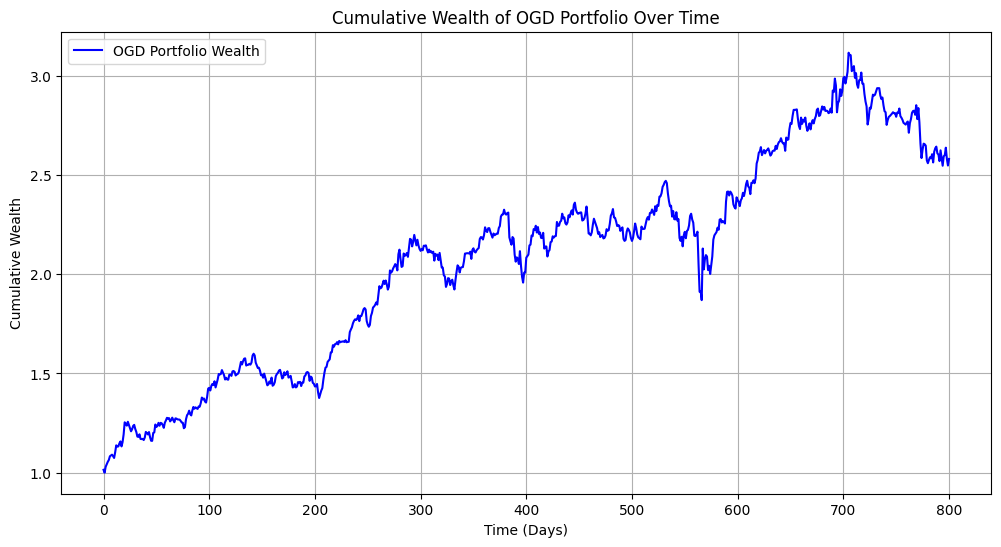

In [6]:
# plot the cumulative wealth over time
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(wealth_ogd, label='OGD Portfolio Wealth', color='blue')
plt.title('Cumulative Wealth of OGD Portfolio Over Time')
plt.xlabel('Time (Days)')
plt.ylabel('Cumulative Wealth')
plt.legend()
plt.grid()
plt.show()

## Online Newton Step

Algorithm: Online Newton Step for Portfolio Selection

```
Inputs:
  n: Number of available assets
  T: Total number of trading periods
  beta: Step size parameter (tuning constant). Default: 0.5 * min(alpha, 1 / (4 * G * D))
  epsilon: Small positive constant to initialize the matrix. Default: 1 / (beta^2 * D^2)

Initialization:
  Set diameter: D = sqrt(2)
  Set Lipschitz constant: G = c^2 * sqrt(2n)
  Set exp_concativy constant: alpha = 1
  Set initial portfolio: x_1 = [1/n, 1/n, ..., 1/n] 
  Set initial inverse matrix: A_inv_0 = (1 / epsilon) * I  (where I is the n x n identity matrix)

For t = 1 to T:
  1. Allocate wealth according to portfolio vector x_t.
  2. Observe the market return vector r_t.
  3. Compute the gradient of the log-loss: 
     g_t = -(r_t) / dot_product(r_t, x_t)
     
  4. Update the inverse matrix A_inv_t using the Sherman-Morrison formula:
     numerator = A_inv_{t-1} * g_t * g_t^T * A_inv_{t-1}
     denominator = 1 + g_t^T * A_inv_{t-1} * g_t
     A_inv_t = A_inv_{t-1} - (numerator / denominator)
     
  5. Perform the Newton-scaled gradient step: 
     y_{t+1} = x_t - (1 / beta) * (A_inv_t * g_t)
     
  6. Project the updated weights back onto the simplex using the A_t norm: 
     x_{t+1} = argmin_{x in Simplex} (x - y_{t+1})^T * A_t * (x - y_{t+1})
```


In [23]:
import numpy as np
import cvxpy as cp

def project_with_cvxpy(y_target, A_matrix):
    """
    Projects y_target onto the probability simplex using the Mahalanobis distance induced by A_matrix.
    """
    n = len(y_target)
    x = cp.Variable(n)
    A_sym = (A_matrix + A_matrix.T) / 2.0
    
    objective = cp.Minimize(cp.quad_form(x - y_target, cp.psd_wrap(A_sym)))
    constraints = [cp.sum(x) == 1, x >= 0]
    
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.OSQP) 
    
    x_val = np.clip(x.value, 0, 1)
    return x_val / np.sum(x_val)

def run_ons_portfolio(returns_matrix, beta=None, epsilon=None, c=2.0):
    """
    Runs Online Newton Step with theoretically optimal defaults for O(log T) regret.
    
    Args:
        returns_matrix: A NumPy array of shape (T, n)
        beta: Step size parameter. Defaults to theory if None.
        epsilon: Initialization constant. Defaults to theory if None.
        c: Maximum multiplicative price change bound (used to compute G).
    """
    T, n = returns_matrix.shape
    print(f"Running ONS on a {T} x {n} return matrix...")
    
    # --- 1. Compute Theoretical Constants ---
    if beta is None or epsilon is None:
        D = np.sqrt(2)              # Diameter of the simplex
        G = (c**2) * np.sqrt(n)     # Lipschitz constant bound
        alpha = 1.0                 # Exp-concavity constant of -log(x)
        
        if beta is None:
            beta = 0.5 * min(alpha, 1 / (4 * G * D))
            
        if epsilon is None:
            epsilon = 1 / ((beta**2) * (D**2))
            
    print(f"Running ONS with beta = {beta:.5f}, epsilon = {epsilon:.5f}")
    # ----------------------------------------

    # Tracking arrays
    portfolio_weights = np.zeros((T, n))
    portfolio_returns = np.zeros(T)
    
    # Initialization
    x_t = np.ones(n) / n
    A_t = np.eye(n) * epsilon       
    A_inv_t = np.eye(n) / epsilon   

    for t in range(T):
        portfolio_weights[t] = x_t
        r_t = returns_matrix[t]
        
        daily_return = np.dot(x_t, r_t)
        portfolio_returns[t] = daily_return
        
        # Gradient
        g_t = -r_t / daily_return
        
        # Update A_t
        A_t = A_t + np.outer(g_t, g_t)
        
        # Sherman-Morrison fast inverse update
        numerator = A_inv_t @ np.outer(g_t, g_t) @ A_inv_t
        denominator = 1 + np.dot(g_t, A_inv_t @ g_t)
        A_inv_t = A_inv_t - (numerator / denominator)
        
        # Newton-scaled gradient step
        y_next = x_t - (1 / beta) * (A_inv_t @ g_t)
        
        # Mahalanobis Projection
        x_t = project_with_cvxpy(y_next, A_t)

    cumulative_wealth = np.cumprod(portfolio_returns)
    return portfolio_weights, cumulative_wealth

In [29]:
# --- Execution Example ---
# Assuming T_x_n_matrix is loaded in your environment

# Run ONS (tuning beta and epsilon might be necessary depending on the scale of your returns)
weights_ons, wealth_ons = run_ons_portfolio(T_x_n_matrix, 0.5, 1.0)

print(f"\nFinal ONS Portfolio Value (assuming $1 starting wealth): ${wealth_ons[-1]:.2f}")

Running ONS on a 801 x 7 return matrix...
Running ONS with beta = 0.50000, epsilon = 1.00000

Final ONS Portfolio Value (assuming $1 starting wealth): $2.73


## Plotting trends

Baseline: S&P500

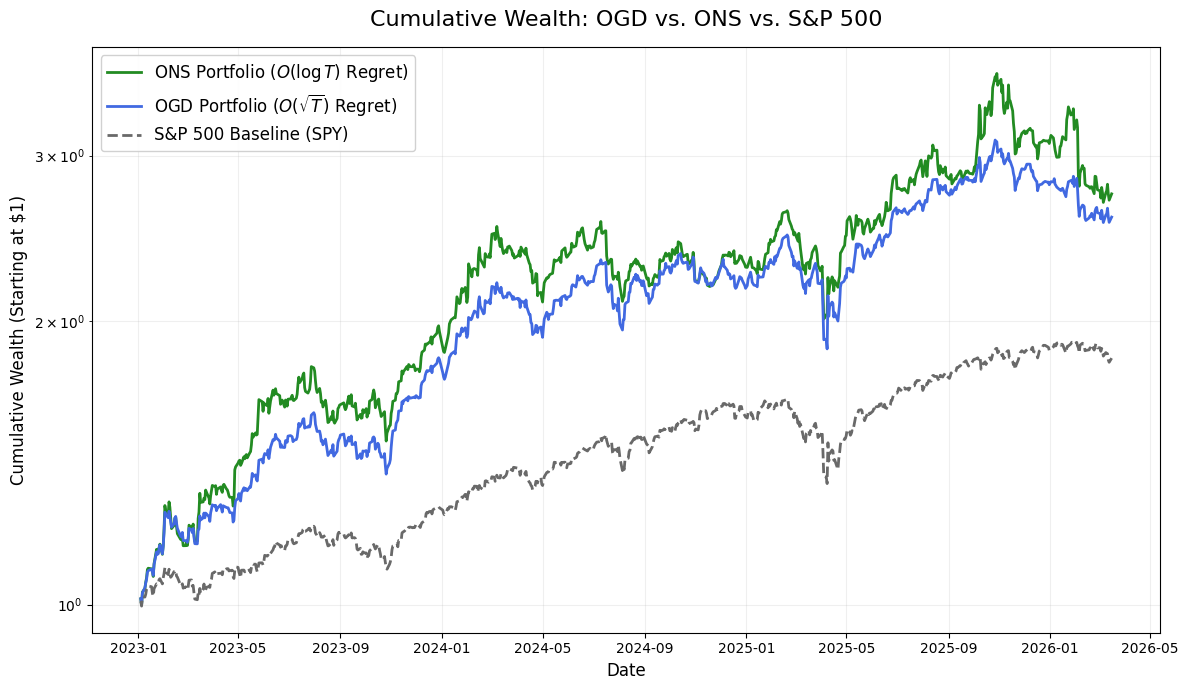

In [31]:
import matplotlib.pyplot as plt
import numpy as np

def plot_wealth_trajectories(return_data, wealth_ogd, wealth_ons):
    """
    Plots the cumulative wealth of OGD, ONS, and the SPY baseline.
    
    Args:
        return_data: The pandas DataFrame containing the daily multiplicative returns.
        wealth_ogd: The cumulative wealth array from the OGD algorithm.
        wealth_ons: The cumulative wealth array from the ONS algorithm.
    """
    # 1. Calculate the baseline: Buy and hold SPY
    # SPY represents our broad market index baseline
    spy_returns = return_data['SPY'].to_numpy()
    wealth_spy = np.cumprod(spy_returns)
    
    # 2. Extract the dates for the x-axis
    dates = return_data.index
    
    # 3. Set up the plot aesthetics
    plt.figure(figsize=(12, 7))
    
    # Plot the three wealth curves
    plt.plot(dates, wealth_ons, label='ONS Portfolio ($O(\\log T)$ Regret)', color='forestgreen', linewidth=2)
    plt.plot(dates, wealth_ogd, label='OGD Portfolio ($O(\\sqrt{T})$ Regret)', color='royalblue', linewidth=2)
    plt.plot(dates, wealth_spy, label='S&P 500 Baseline (SPY)', color='dimgray', linestyle='--', linewidth=2)
    
    # 4. Formatting the chart
    plt.title('Cumulative Wealth: OGD vs. ONS vs. S&P 500', fontsize=16, pad=15)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Cumulative Wealth (Starting at $1)', fontsize=12)
    
    # Use a log scale for the y-axis to accurately reflect compounding percentage growth
    plt.yscale('log')
    
    # Add gridlines, legend, and layout adjustments
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.legend(loc='upper left', fontsize=12, framealpha=0.9)
    plt.tight_layout()
    
    # 5. Render the plot
    plt.show()

# --- Execution Example ---
# Run this after you have generated wealth_ogd and wealth_ons from the previous steps
plot_wealth_trajectories(return_data, wealth_ogd, wealth_ons)

#### Maximum Drawdown (MDD)

Maximum Drawdown (MDD) is one of the most critical risk metrics in quantitative finance. While theoretical regret bounds guarantee that your algorithm will eventually compound wealth, they do not protect you from severe short-term losses along the way. 



Maximum drawdown measures the largest single percentage drop from a historical peak to a subsequent trough before a new peak is reached. Mathematically, for a wealth trajectory $W$ over time $t$:

$$MDD = \min_{t} \left( \frac{W_t - \max_{\tau \le t} W_\tau}{\max_{\tau \le t} W_\tau} \right)$$


How to Interpret the Results

* **Risk vs. Reward:** If ONS achieved a higher final cumulative wealth than SPY, but its MDD was **-45%** compared to SPY's **-20%**, the algorithm is taking on significantly more risk to generate those returns. In a real-world scenario, a severe drawdown might force a practitioner to liquidate before the algorithm has time to recover.
* **The Volatility Drag:** Because ONS dynamically adjusts to the covariance of the assets (using the $A_t$ matrix), it is often better at sidestepping severe correlated market crashes than OGD. You will typically see ONS register a shallower maximum drawdown than OGD, confirming its $O(\log T)$ theoretical superiority in a practical setting.

#### Implementation

In [15]:
import numpy as np

def print_maximum_drawdowns(wealth_ogd, wealth_ons, wealth_spy):
    """
    Calculates and prints the Maximum Drawdown (MDD) for three wealth trajectories.
    
    Args:
        wealth_ogd: Cumulative wealth array for OGD.
        wealth_ons: Cumulative wealth array for ONS.
        wealth_spy: Cumulative wealth array for the SPY baseline.
    """
    def calculate_mdd(wealth_array):
        # 1. Track the running maximum (highest peak seen up to each point in time)
        running_max = np.maximum.accumulate(wealth_array)
        
        # 2. Calculate the percentage drop from the running max at every point
        # We use a safe division (though running_max should never be zero for wealth)
        drawdowns = (wealth_array - running_max) / running_max
        
        # 3. The maximum drawdown is the lowest (most negative) value in this array
        max_drawdown = np.min(drawdowns)
        
        return max_drawdown

    # Calculate MDD for each strategy
    mdd_ogd = calculate_mdd(wealth_ogd)
    mdd_ons = calculate_mdd(wealth_ons)
    mdd_spy = calculate_mdd(wealth_spy)

    # Print the results formatted as percentages
    print("\n--- Maximum Drawdowns (Risk Analysis) ---")
    print(f"ONS Portfolio MDD: {mdd_ons * 100:.2f}%")
    print(f"OGD Portfolio MDD: {mdd_ogd * 100:.2f}%")
    print(f"S&P 500 (SPY) MDD: {mdd_spy * 100:.2f}%")

# --- Execution Example ---
# Calculate the baseline wealth (assuming return_data is your pandas DataFrame)
spy_returns = return_data['SPY'].to_numpy()
wealth_spy = np.cumprod(spy_returns)

# Call the function
print_maximum_drawdowns(wealth_ogd, wealth_ons, wealth_spy)


--- Maximum Drawdowns (Risk Analysis) ---
ONS Portfolio MDD: -24.33%
OGD Portfolio MDD: -24.34%
S&P 500 (SPY) MDD: -18.76%
